## MAT 443 ERIC BAAH - FINAL EXAM

In [74]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc, classification_report
import warnings
from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, BaggingClassifier, RandomForestClassifier
from ISLP.models import bs, ns
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from ISLP.models import (ModelSpec as MS, summarize, poly)
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,export_text)
import seaborn as sns
from xgboost import XGBRegressor as XGB
from lightgbm import LGBMRegressor as LGBMR
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,degrees_of_freedom, plot as plot_gam, anova as anova_gam)

In [75]:
# Load the dataset
train = pd.read_csv("train_data443_2024.csv")
test = pd.read_csv("test_data443_2024.csv")  

# Recode the binary variable
train['class'] = train['class'].map({'anomaly': 1, 'normal': 0})
test['class'] = test['class'].map({'anomaly': 1, 'normal': 0})

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data = pd.concat([train, test], keys=["train", "test"])

data = data.apply(lambda col: label_encoder.fit_transform(col) if col.dtype == 'object' else col)

train = data.xs('train')
test = data.xs('test')

# Training features (X) and target (y)
X_train = train.drop(columns=['class'])
X_test = test.drop(columns=['class'])
y_train = train['class']  # Target variable Train
y_test = test['class']  # Target variable Test


## (A) Bagging

In [61]:
#BAGGING 

Bagging = MS(train.columns.drop(['class']), intercept=True)
D = Bagging.fit_transform(train)
feature_names = list(D.columns)
X = np.asarray(D)

# Initialize and fit a Bagging Classifier
bagging = RandomForestRegressor(max_features=X_train.shape[1], random_state=0)
bagging_result = bagging.fit(X_train, y_train)

# Predict on the test set
y_prob_bagging = bagging.predict(X_test)
y_pred_bagging = (y_prob_bagging > 0.5).astype(int)

# Calculate the confusion matrix
Bagging_CM = confusion_matrix(y_test, y_pred_bagging)

# Convert the confusion matrix into a DataFrame for better readability with labels
Bagging_CM_df = pd.DataFrame(Bagging_CM, index=['True: Normal', 'True: Anomaly'], columns=['Pred: Normal', 'Pred: Anomaly'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(Bagging_CM_df)

Accuracy = accuracy_score(y_test, y_pred_bagging)
print(f"Accuracy Score: {Accuracy}")

# Extract values from the confusion matrix
TN, FP, FN, TP = Bagging_CM.ravel()

# Calculate False Positive Rate, False Negative Rate, True Positive Rate
true_positive_rate = TP / (TP + FN)   # TPR (Recall) = TP / (TP + FN)
true_negative_rate = TN / (TN + FP)   # TNR = TN / (TN + FP)

print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"Sensitivity: {true_positive_rate:.4f}")
print(f"Specificty: {true_negative_rate:.4f}")

Confusion Matrix:
               Pred: Normal  Pred: Anomaly
True: Normal           6711             14
True: Anomaly            59           8162
Accuracy Score: 0.9951157500334538
False Positive (FP): 14
False Negative (FN): 59
Sensitivity: 0.9928
Specificty: 0.9979


## (B) Random Forest

In [63]:
# RANDOM FOREST

# Initialize and fit a RF Classifier
RF = RandomForestRegressor(max_features='sqrt', random_state=0)
RF_result = RF.fit(X_train, y_train)

# Predict on the test set
y_prob_RF = RF.predict(X_test)
y_pred_RF = (y_prob_RF > 0.5).astype(int)

# Calculate the confusion matrix
RF_CM = confusion_matrix(y_test, y_pred_RF)

# Convert the confusion matrix into a DataFrame for better readability with labels
RF_CM_df = pd.DataFrame(RF_CM, index=['True: Normal', 'True: Anomaly'], columns=['Pred: Normal', 'Pred: Anomaly'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(RF_CM_df)

Accuracy = accuracy_score(y_test, y_pred_RF)
print(f"Accuracy Score: {Accuracy}")

# Extract values from the confusion matrix
TN, FP, FN, TP = RF_CM.ravel()

# Calculate False Positive Rate, False Negative Rate, True Positive Rate
true_positive_rate = TP / (TP + FN)   # TPR (Recall) = TP / (TP + FN)
true_negative_rate = TN / (TN + FP)   # TNR = TN / (TN + FP)

print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"Sensitivity: {true_positive_rate:.4f}")
print(f"Specificty: {true_negative_rate:.4f}")

Confusion Matrix:
               Pred: Normal  Pred: Anomaly
True: Normal           6717              8
True: Anomaly            61           8160
Accuracy Score: 0.995383380168607
False Positive (FP): 8
False Negative (FN): 61
Sensitivity: 0.9926
Specificty: 0.9988


## (C) 

The confusion matrix and metrics indicate that both Bagging and Random Forest achieve high classification performance, with slight differences in false positives (FP), false negatives (FN), sensitivity, and specificity. Bagging results in 14 FP and 59 FN, whereas Random Forest achieves lower FP (8) but slightly higher FN (61). Sensitivity, which measures the ability of the model to correctly identify the "Anomaly" class, is slightly higher in Bagging (99.28%) than Random Forest (99.26%). However, specificity, which measures the ability to correctly classify the "Normal" class, is higher for Random Forest (99.88%) compared to Bagging (99.79%). This suggests that Random Forest is slightly better at avoiding FP, whereas Bagging is slightly better at minimizing FN.

Given that we're interested in detecting Malicious network flow, FN is the most important rate because we want to at all cost, avoid the possibility of not detecting Malicious network flow given that we actually have a Malicious network flow. Given that we have a 61 FN in the Random forest, it is not good enough because we're still unable to detect a good number of these cases. One way to improve the model is to reduce the classification threshold. Reducing the classification threshold from the default value of 0.5 can help in reducing FN. By lowering the threshold, the model becomes more sensitive to predicting the "Anomaly" class, as it will classify more instances as anomalies even when their predicted probability is relatively low. This will increase the recall (sensitivity), reducing the number of false negatives, but may also increase the false positives as a trade-off. 

For applications where the cost of missing an anomaly is higher than incorrectly flagging a normal instance, reducing the threshold can be a beneficial strategy to prioritize detecting all anomalies. Below is how to reduce the threshold and run both the bagging and random forest.

In [49]:
#### Threshold Adjustment Code

def evaluate_threshold(model, X_test, y_test, thresholds):
    results = []
    y_prob = model.predict(X_test)  # Get probabilities for the positive class

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results.append({
            'Threshold': threshold,
            'FP': fp,
            'FN': fn,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'Precision': precision,
            'F1 Score': f1
        })

    return results

# Define thresholds to test
thresholds = np.arange(0.1, 1.0, 0.1)

# Evaluate for Bagging
bagging_threshold_results = evaluate_threshold(bagging, X_test, y_test, thresholds)

# Evaluate for Random Forest
rf_threshold_results = evaluate_threshold(RF, X_test, y_test, thresholds)

# Display results
import pandas as pd
bagging_results_df = pd.DataFrame(bagging_threshold_results)
rf_results_df = pd.DataFrame(rf_threshold_results)

print(bagging_results_df)
print(rf_results_df)

print(f"From the results, we clearly see that we reduce FN by reducing the threshold, therefore the best way to improve whta I care about is to fix the threshold to 0.1")

   Threshold   FP   FN  Sensitivity  Specificity  Precision  F1 Score
0        0.1  119   21     0.997446     0.982305   0.985695  0.991536
1        0.2   63   34     0.995864     0.990632   0.992364  0.994111
2        0.3   37   40     0.995134     0.994498   0.995498  0.995316
3        0.4   24   49     0.994040     0.996431   0.997072  0.995553
4        0.5   15   56     0.993188     0.997770   0.998166  0.995671
5        0.6    9   65     0.992093     0.998662   0.998898  0.995484
6        0.7    4   86     0.989539     0.999405   0.999509  0.994499
7        0.8    3  111     0.986498     0.999554   0.999630  0.993021
8        0.9    0  153     0.981389     1.000000   1.000000  0.990607
   Threshold   FP   FN  Sensitivity  Specificity  Precision  F1 Score
0        0.1  126    9     0.998905     0.981264   0.984888  0.991847
1        0.2   48   17     0.997932     0.992862   0.994183  0.996054
2        0.3   23   36     0.995621     0.996580   0.997198  0.996409
3        0.4   11   

In [66]:
#BAGGING 

Bagging_thresh = MS(train.columns.drop(['class']), intercept=True)
D = Bagging_thresh.fit_transform(train)
feature_names = list(D.columns)
X = np.asarray(D)

# Initialize and fit a Bagging Classifier
bagging_thresh = RandomForestRegressor(max_features=X_train.shape[1], random_state=0)
bagging_result_tresh = bagging_thresh.fit(X_train, y_train)

# Predict on the test set
y_prob_bagging_thresh = bagging_thresh.predict(X_test)
y_pred_bagging_thresh = (y_prob_bagging_thresh > 0.1).astype(int)

# Calculate the confusion matrix
Bagging_CM_thresh = confusion_matrix(y_test, y_pred_bagging_thresh)

# Convert the confusion matrix into a DataFrame for better readability with labels
Bagging_CM_thresh_df = pd.DataFrame(Bagging_CM_thresh, index=['True: Normal', 'True: Anomaly'], columns=['Pred: Normal', 'Pred: Anomaly'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(Bagging_CM_thresh_df)

Accuracy = accuracy_score(y_test, y_pred_bagging_thresh)
print(f"Accuracy Score: {Accuracy}")

# Extract values from the confusion matrix
TN, FP, FN, TP = Bagging_CM_thresh.ravel()

# Calculate False Positive Rate, False Negative Rate, True Positive Rate
true_positive_rate = TP / (TP + FN)   # TPR (Recall) = TP / (TP + FN)
true_negative_rate = TN / (TN + FP)   # TNR = TN / (TN + FP)

print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"Sensitivity: {true_positive_rate:.4f}")
print(f"Specificty: {true_negative_rate:.4f}")

Confusion Matrix:
               Pred: Normal  Pred: Anomaly
True: Normal           6619            106
True: Anomaly            24           8197
Accuracy Score: 0.9913020206075204
False Positive (FP): 106
False Negative (FN): 24
Sensitivity: 0.9971
Specificty: 0.9842


In [76]:
# RANDOM FOREST WITH THRESHOLD

# Initialize and fit a RF Classifier
RF_thresh = RandomForestRegressor(max_features='sqrt', random_state=0)
RF_result_thresh = RF_thresh.fit(X_train, y_train)

# Predict on the test set
y_prob_RF = RF_thresh.predict(X_test)
y_pred_RF = (y_prob_RF > 0.1).astype(int)

# Calculate the confusion matrix
RF_CM = confusion_matrix(y_test, y_pred_RF)

# Convert the confusion matrix into a DataFrame for better readability with labels
RF_CM_df = pd.DataFrame(RF_CM, index=['True: Normal', 'True: Anomaly'], columns=['Pred: Normal', 'Pred: Anomaly'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(RF_CM_df)

Accuracy = accuracy_score(y_test, y_pred_RF)
print(f"Accuracy Score: {Accuracy}")

# Extract values from the confusion matrix
TN, FP, FN, TP = RF_CM.ravel()

print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"Sensitivity: {true_positive_rate:.4f}")
print(f"Specificty: {true_negative_rate:.4f}")

print(f"After reducing the threshold from 0.5 to 0.1, the FN reduces from 61 to 9 but at the expense of FP increasing from 8 to 114.")

Confusion Matrix:
               Pred: Normal  Pred: Anomaly
True: Normal           6611            114
True: Anomaly             9           8212
Accuracy Score: 0.9917703733440385
False Positive (FP): 114
False Negative (FN): 9
Sensitivity: 0.9971
Specificty: 0.9842
After reducing the threshold from 0.5 to 0.1, the FN reduces from 61 to 9 but at the expense of FP increasing from 8 to 114.


## (D) Two Boosting Methods

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
gb_model = GradientBoostingClassifier(random_state=0)

# Define the hyperparameter grid
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# Perform GridSearchCV
gb_grid_search = GridSearchCV(estimator=gb_model, param_grid=gb_param_grid,
                              scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters for Gradient Boosting:", gb_grid_search.best_params_)
print("Best Accuracy for Gradient Boosting:", gb_grid_search.best_score_)


In [68]:
# Gradient Boosting
GB = GBR(n_estimators=300, learning_rate =0.1, max_depth=5, random_state=0, subsample=1.0)
GB_result = GB.fit(X_train, y_train)
y_prob_GB = GB.predict(X_test)
y_pred_GB = (y_prob_GB > 0.5).astype(int)

# Calculate the confusion matrix
GB_CM = confusion_matrix(y_test, y_pred_GB)

# Convert the confusion matrix into a DataFrame for better readability with labels
GB_CM_df = pd.DataFrame(GB_CM, index=['True: Normal', 'True: Anomaly'], columns=['Pred: Normal', 'Pred: Anomaly'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(GB_CM_df)

Accuracy = accuracy_score(y_test, y_pred_GB)
print(f"Accuracy Score: {Accuracy}")

# Extract values from the confusion matrix
TN, FP, FN, TP = GB_CM.ravel()

print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"Sensitivity: {true_positive_rate:.4f}")
print(f"Specificty: {true_negative_rate:.4f}")

Confusion Matrix:
               Pred: Normal  Pred: Anomaly
True: Normal           6716              9
True: Anomaly            64           8157
Accuracy Score: 0.9951157500334538
False Positive (FP): 9
False Negative (FN): 64
Sensitivity: 0.9971
Specificty: 0.9842


In [53]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define the hyperparameter grid
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'colsample_bytree': [0.8, 1.0],
    'subsample': [0.8, 1.0]
}

# Perform GridSearchCV
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid,
                               scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters for XGBoost:", xgb_grid_search.best_params_)
print("Best Accuracy for XGBoost:", xgb_grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\Users\erick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\core.py:158: UserWarning: [20:48:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best Accuracy for XGBoost: 0.9973648537656679


In [69]:
# XGBoost

XG_Boost = XGB(colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=300, random_state=0, subsample=1.0)
XGB_result = XG_Boost.fit(X_train, y_train)
y_prob_XGB = XG_Boost.predict(X_test)
y_pred_XGB = (y_prob_XGB > 0.5).astype(int)

# Calculate the confusion matrix
XGB_CM = confusion_matrix(y_test, y_pred_XGB)

# Convert the confusion matrix into a DataFrame for better readability with labels
XGB_CM_df = pd.DataFrame(XGB_CM, index=['True: Normal', 'True: Anomaly'], columns=['Pred: Normal', 'Pred: Anomaly'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(XGB_CM_df)

Accuracy = accuracy_score(y_test, y_pred_XGB)
print(f"Accuracy Score: {Accuracy}")

# Extract values from the confusion matrix
TN, FP, FN, TP = XGB_CM.ravel()

print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"Sensitivity: {true_positive_rate:.4f}")
print(f"Specificty: {true_negative_rate:.4f}")

Confusion Matrix:
               Pred: Normal  Pred: Anomaly
True: Normal           6715             10
True: Anomaly            49           8172
Accuracy Score: 0.99605245550649
False Positive (FP): 10
False Negative (FN): 49
Sensitivity: 0.9971
Specificty: 0.9842


## (E) Boosting with Random Forest Comparison

The table indicates that Random Forest with a classification threshold of 0.1 achieves the lowest false negative rate (FNR = 0.06%), making it the most effective model in this analysis for detecting anomalies, which is the primary concern. This low FNR suggests that the model successfully minimizes missed anomalies (false negatives), a critical aspect of anomaly detection tasks. While the accuracy of this model (99.18%) is slightly lower compared to others like XGBoost (99.61%), its enhanced ability to detect the positive class (anomalies) makes it the most suitable choice for this problem.

XGBoost, on the other hand, achieves the highest overall accuracy (99.61%) and a relatively low FNR of 0.33%, demonstrating its strong general performance. However, the higher FNR compared to Random Forest at the 0.1 threshold means it misses more anomalies, which could be problematic in scenarios where false negatives are costly. The performance of XGBoost in terms of sensitivity (99.71%) is on par with Random Forest at the 0.1 threshold, indicating its ability to detect anomalies effectively, albeit with a trade-off in false negatives.

Gradient Boosting and Bagging models, while performing well overall, have slightly higher FNRs (0.43% for Gradient Boosting and 0.39% for Bagging), making them less suitable for anomaly detection where minimizing false negatives is crucial. The standard Random Forest (default threshold) also has a higher FNR (0.41%) compared to its lower-threshold counterpart, indicating that adjusting the classification threshold is a critical step in optimizing the model for the given objective.

Random Forest leverages bagging, which involves training multiple decision trees on bootstrapped datasets and averaging their predictions. This approach reduces variance and prevents overfitting, making it robust and effective for general classification tasks. However, Random Forest does not prioritize hard-to-classify observations as boosting methods do, which explains its slightly lower sensitivity. The difference in performance between Random Forest at the 0.1 threshold and the other models can be attributed to the impact of the threshold adjustment. By lowering the threshold, the model becomes more sensitive to the positive class, classifying instances as anomalies even when their predicted probability is relatively low. This adjustment directly reduces false negatives (FNR) but increases the false positive rate (FPR), as seen in the table (FPR = 0.76% for Random Forest with a 0.1 threshold). The trade-off here is acceptable in this context, as minimizing false negatives is more important than a slight increase in false positives.

In conclusion, Random Forest with a 0.1 classification threshold is the best choice for this analysis due to its lowest FNR (0.06%), which aligns with the goal of anomaly detection. The slight compromise in specificity and accuracy is acceptable given the significant improvement in minimizing missed anomalies. XGBoost remains a strong contender for scenarios where a balance between FNR and overall accuracy is desired, but for this specific task, Random Forest with the adjusted threshold stands out.

## (F) Top 5 Features and Rerun

                               Importance
src_bytes                    1.597124e-01
same_srv_rate                1.056398e-01
flag                         9.488850e-02
dst_bytes                    8.304435e-02
diff_srv_rate                6.718206e-02
dst_host_serror_rate         4.644462e-02
dst_host_srv_count           4.289069e-02
dst_host_same_src_port_rate  3.727601e-02
protocol_type                3.712415e-02
dst_host_same_srv_rate       3.525536e-02
dst_host_srv_serror_rate     3.344187e-02
count                        3.015187e-02
srv_serror_rate              2.576018e-02
logged_in                    2.372903e-02
service                      2.046470e-02
dst_host_diff_srv_rate       2.039976e-02
srv_count                    2.016828e-02
dst_host_srv_diff_host_rate  1.810824e-02
dst_host_count               1.779271e-02
serror_rate                  1.375146e-02
dst_host_srv_rerror_rate     1.324577e-02
rerror_rate                  1.061514e-02
dst_host_rerror_rate         9.619

C:\Users\erick\AppData\Local\Temp\ipykernel_60232\3415124889.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y=top_5.index, data=top_5, palette='viridis')


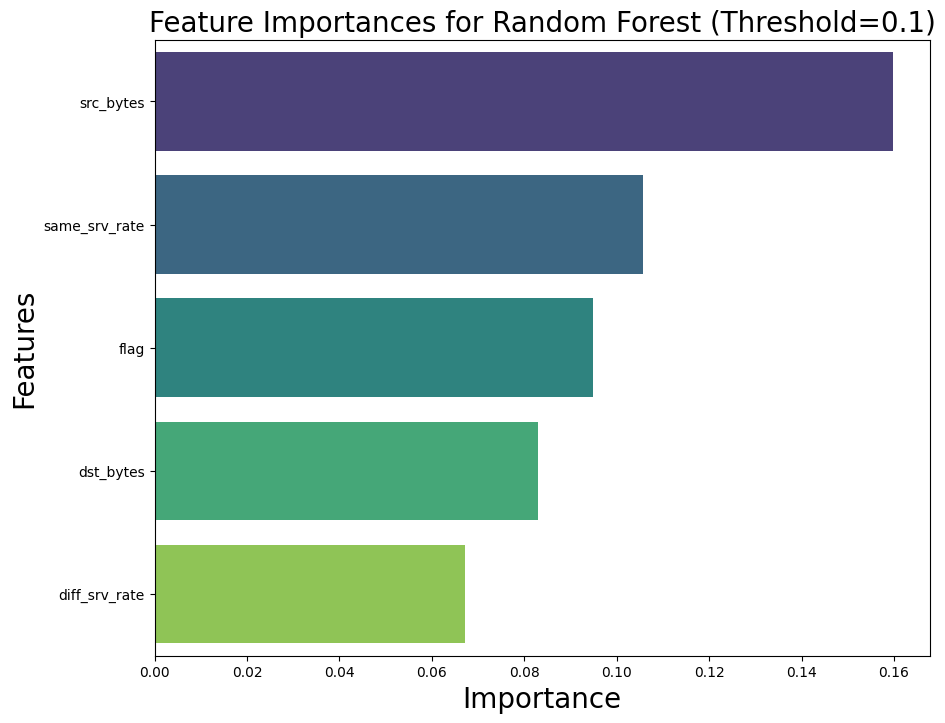

In [77]:
# Feature importance for Bagging
feature_imp = pd.DataFrame(
{'Importance':RF_result_thresh.feature_importances_},
index=X_train.columns)
print(feature_imp.sort_values(by='Importance', ascending=False))

# Sort by feature importance and select the top 10
top_5 = feature_imp.nlargest(5, 'Importance')

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y=top_5.index, data=top_5, palette='viridis')
plt.title('Feature Importances for Random Forest (Threshold=0.1)', fontsize=20)
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Features', fontsize=20)
plt.savefig('RF_features.png')
plt.show()

In [78]:

# Training features (X)
X_train = train.drop(columns=['class', 'src_bytes', 'same_srv_rate', 'flag', 'dst_bytes', 'diff_srv_rate'])
X_test = test.drop(columns=['class', 'src_bytes', 'same_srv_rate', 'flag', 'dst_bytes', 'diff_srv_rate'])

# RANDOM FOREST WITH THRESHOLD

# Initialize and fit a RF Classifier
RF_thresh = RandomForestRegressor(max_features='sqrt', random_state=0)
RF_result_thresh_res = RF_thresh.fit(X_train, y_train)

# Predict on the test set
y_prob_RF = RF_thresh.predict(X_test)
y_pred_RF = (y_prob_RF > 0.1).astype(int)

# Calculate the confusion matrix
RF_CM = confusion_matrix(y_test, y_pred_RF)

# Convert the confusion matrix into a DataFrame for better readability with labels
RF_CM_df = pd.DataFrame(RF_CM, index=['True: Normal', 'True: Anomaly'], columns=['Pred: Normal', 'Pred: Anomaly'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(RF_CM_df)

Accuracy = accuracy_score(y_test, y_pred_RF)
print(f"Accuracy Score: {Accuracy}")

# Extract values from the confusion matrix
TN, FP, FN, TP = RF_CM.ravel()

print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"Sensitivity: {true_positive_rate:.4f}")
print(f"Specificty: {true_negative_rate:.4f}")


Confusion Matrix:
               Pred: Normal  Pred: Anomaly
True: Normal           6563            162
True: Anomaly            10           8211
Accuracy Score: 0.9884919041884116
False Positive (FP): 162
False Negative (FN): 10
Sensitivity: 0.9971
Specificty: 0.9842


                               Importance
dst_host_same_srv_rate       1.072064e-01
dst_host_srv_count           9.613562e-02
serror_rate                  8.942615e-02
srv_serror_rate              7.810919e-02
dst_host_diff_srv_rate       6.104950e-02
dst_host_srv_serror_rate     5.377038e-02
dst_host_serror_rate         5.323368e-02
protocol_type                4.979155e-02
count                        4.901656e-02
dst_host_same_src_port_rate  4.606510e-02
service                      4.220663e-02
dst_host_srv_rerror_rate     3.994047e-02
logged_in                    3.990543e-02
dst_host_rerror_rate         3.166651e-02
dst_host_count               3.054104e-02
dst_host_srv_diff_host_rate  2.742508e-02
srv_count                    2.612234e-02
srv_rerror_rate              2.365684e-02
rerror_rate                  1.609459e-02
wrong_fragment               8.738300e-03
hot                          8.176834e-03
num_compromised              7.674717e-03
srv_diff_host_rate           6.634

C:\Users\erick\AppData\Local\Temp\ipykernel_60232\1091019163.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y=top_5.index, data=top_5, palette='viridis')


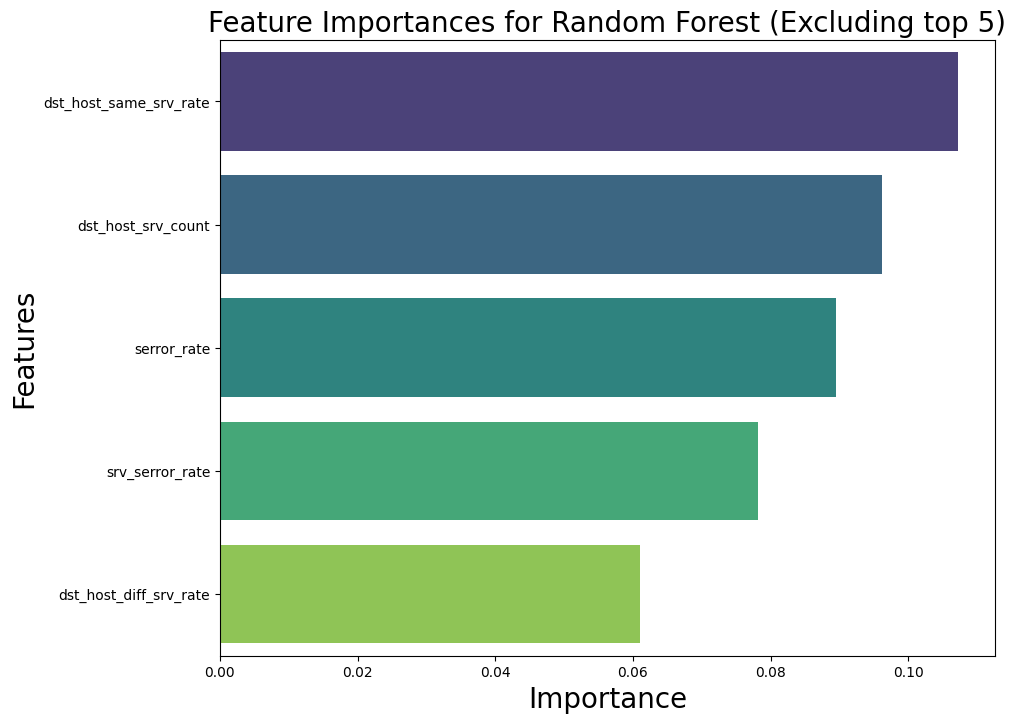

In [79]:
# Feature importance for Bagging
feature_imp = pd.DataFrame(
{'Importance':RF_result_thresh_res.feature_importances_},
index=X_train.columns)
print(feature_imp.sort_values(by='Importance', ascending=False))

# Sort by feature importance and select the top 10
top_5 = feature_imp.nlargest(5, 'Importance')

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y=top_5.index, data=top_5, palette='viridis')
plt.title('Feature Importances for Random Forest (Excluding top 5)', fontsize=20)
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Features', fontsize=20)
plt.savefig('RF_features_res.png')
plt.show()

We observe from the results above that after excluding top 5 features from the Random Forest with 0.1 classification threshold, FN increased from 9 to 10 while FP also increased from 114 to 162. The worsening of the model reaffirms the importance of the 5 most important features that were excluded from the most recent model.

## I

The results indicate that the Random Forest model with a threshold of 0.1 is the best-performing model for this task. It achieves the lowest false negative rate (FNR = 0.06%), which is critical for anomaly detection tasks where missing an anomaly is more costly than classifying a normal instance as anomalous. Despite its slightly lower accuracy (99.18%) compared to XGBoost (99.61%), the minimized FNR and high sensitivity (99.71%) make this model the most effective in the given context. The trade-off is a higher false positive rate (FPR = 0.76%) and slightly reduced specificity (98.42%), but these are acceptable given the importance of detecting anomalies.

The feature importance plot for the Random Forest model highlights that src_bytes is the most important feature, followed by same_srv_rate, flag, dst_bytes, and diff_srv_rate. These features are critical in distinguishing between normal and anomalous network flows. For example:

src_bytes likely captures the volume of data sent, which can differ significantly between normal and malicious activities. same_srv_rate may indicate how frequently the same service is accessed, which could highlight suspicious patterns. Other features, such as flag and dst_bytes, also provide valuable context in identifying anomalies.
The Random Forest model performs well because it excels at handling feature interactions and non-linear relationships in the data. Additionally, lowering the classification threshold increases the model's sensitivity to anomalies, ensuring a low FNR.To further improve the performance of the Random Forest model, one approach is to optimize its hyperparameters using a grid search or random search. Below is an example Python code for improving the model using hyperparameter tuning:


In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

X_train = train.drop(columns=['class'])
X_test = test.drop(columns=['class'])

# Define the model
rf_model = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           scoring='f1', cv=5, verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters and retrain the model
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_rf_model = RandomForestClassifier(**best_params, random_state=42)
best_rf_model.fit(X_train, y_train)

# Predict on the test set
y_prob_RF = best_rf_model.predict(X_test)
y_pred_RF = (y_prob_RF > 0.1).astype(int)

# Calculate the confusion matrix
RF_CM_best = confusion_matrix(y_test, y_pred_RF)

# Convert the confusion matrix into a DataFrame for better readability with labels
RF_CM_best_df = pd.DataFrame(RF_CM_best, index=['True: Normal', 'True: Anomaly'], columns=['Pred: Normal', 'Pred: Anomaly'])

# Print the confusion matrix with labels
print("Confusion Matrix:")
print(RF_CM_best_df)

Accuracy = accuracy_score(y_test, y_pred_RF)
print(f"Accuracy Score: {Accuracy}")

# Extract values from the confusion matrix
TN, FP, FN, TP = RF_CM_best.ravel()

print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"Sensitivity: {true_positive_rate:.4f}")
print(f"Specificty: {true_negative_rate:.4f}")



Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Confusion Matrix:
               Pred: Normal  Pred: Anomaly
True: Normal           6718              7
True: Anomaly            58           8163
Accuracy Score: 0.9956510103037602
False Positive (FP): 7
False Negative (FN): 58
Sensitivity: 0.9971
Specificty: 0.9842


Clearly, this is significantly worse than the best model.

## Question 2

### Final Classification Error Using AdaBoost.M1 Algorithm

To compute the weighted error for Step 3 and the final classification error rate, we proceed as follows:

#### Step 1
Initially, each observation is assigned an equal weight since there are 8 observations:

$w_i = \frac{1}{8} = 0.125$

The first weak learner misclassifies: 
1. 2 negative observations. 
2. 1 positive observation. 

The weighted error for the first weak learner is:
\begin{align*}
e_1 = \sum \text{weights of misclassified observations} = 2 \times 0.125 + 1 \times 0.125 = 0.375
\end{align*}

The contribution of the first weak learner ($\alpha_1$) is calculated as:
\begin{align*}
\alpha_1 = \frac{1}{2} \ln\left(\frac{1 - e_1}{e_1}\right) = \frac{1}{2} \ln\left(\frac{1 - 0.375}{0.375}\right) = \frac{1}{2} \ln\left(\frac{0.625}{0.375}\right) = \frac{1}{2} \ln(1.6667) \approx 0.255
\end{align*}

The weights are updated as follows:
1. For correctly classified observations:
    $w_{\text{correct}}^{\text{new}} = w_{\text{correct}}^{\text{old}} \times \exp(-\alpha_1) = 0.125 \times \exp(-0.255) \approx 0.106$
2. For misclassified observations:
    $w_{\text{misclassified}}^{\text{new}} = w_{\text{misclassified}}^{\text{old}} \times \exp(\alpha_1) = 0.125 \times \exp(0.255) \approx 0.146$

To normalize the weights:
$Z = \sum w_i^{\text{new}} = 5 \times 0.106 + 3 \times 0.146 = 0.53 + 0.438 = 0.968$
The normalized weights are:
$w_{\text{correct}}^{\text{Step 1}} = \frac{0.106}{0.968} \approx 0.109, \quad w_{\text{misclassified}}^{\text{Step 1}} = \frac{0.146}{0.968} \approx 0.151$





#### Step 2 

The second weak learner misclassifies:
1. 2 positive observations that were not misclassified by the first weak learner.

The weighted error for the second weak learner is:
$e_2 = \sum \text{weights of misclassified observations} = 2 \times w_{\text{correct}}^{\text{Step 1}} = 2 \times 0.109 = 0.218$

The contribution of the second weak learner ($\alpha_2$) is calculated as:
\begin{align*}
\alpha_2 = \frac{1}{2} \ln\left(\frac{1 - e_2}{e_2}\right) = \frac{1}{2} \ln\left(\frac{1 - 0.218}{0.218}\right) = \frac{1}{2} \ln\left(\frac{0.782}{0.218}\right) = \frac{1}{2} \ln(3.587) \approx 0.639
\end{align*}

The weights are updated as follows:
1. For correctly classified observations:
    $w_{\text{correct}}^{\text{new}} = w_{\text{correct}}^{\text{old}} \times \exp(-\alpha_2) = 0.109 \times \exp(-0.639) \approx 0.058$
2.  For misclassified observations:
    $w_{\text{misclassified}}^{\text{new}} = w_{\text{misclassified}}^{\text{old}} \times \exp(\alpha_2) = 0.151 \times \exp(0.639) \approx 0.286$

To normalize the weights:
$Z = \sum w_i^{\text{new}} = (6 \times 0.058) + (2 \times 0.286) \approx 0.348 + 0.572 = 0.92$

The normalized weights are:
$w_{\text{correct}}^{\text{Step 2}} = \frac{0.058}{0.92} \approx 0.063, \quad w_{\text{misclassified}}^{\text{Step 2}} = \frac{0.286}{0.92} \approx 0.311$

After normalization (ensuring the weights sum to 1), these are the weights to be used for Step 3.




#### Step 3: 
Compute Weighted For the third weak learner:
1. Misclassified observations: 2 negative observations that were misclassified by the first weak   learner but correctly classified by the second, and 1 positive observation that was misclassified only by the second weak learner.
2. Weighted error ($e_3$):
$e_3 = 2 \times w_{\text{negative}} + 1 \times w_{\text{positive}}$ 

Substituting the weights:
$e_3 = 2 \times 0.063 + 1 \times 0.311 = 0.126 + 0.311 = 0.437$

3. Contribution of the third weak learner ($\alpha_3$):
$\alpha_3 = \frac{1}{2} \ln\left(\frac{1 - e_3}{e_3}\right) = \frac{1}{2} \ln\left(\frac{1 - 0.437}{0.437}\right)  = \frac{1}{2} \ln(1.288) \approx 0.127$


Normalize Weights
For all observations:
\begin{align*}
w_{\text{correct}}^{\text{Step 3}} &= w_{\text{correct}}^{\text{Step 2}} \times \exp(-\alpha_3) = 0.063 \times \exp(-0.127) \approx 0.055, \\
w_{\text{misclassified}}^{\text{Step 3}} &= w_{\text{misclassified}}^{\text{Step 2}} \times \exp(\alpha_3) = 0.311 \times \exp(0.127) \approx 0.353
\end{align*}

Normalize the weights:
$Z = \sum w_i = (6 \times 0.055) + (2 \times 0.353) \approx 1.036$

Final normalized weights:
$w_{\text{correct}}^{\text{Step 3, Normalized}} = \frac{0.055}{1.036} \approx 0.053, \quad w_{\text{misclassified}}^{\text{Step 3, Normalized}} = \frac{0.353}{1.036} \approx 0.341$

Final Classification Error
The final classifier combines the contributions ($\alpha$) of all three weak learners:
$H(x) = \text{sign} \left( \sum_{t=1}^3 \alpha_t h_t(x) \right)$

The classification error is the sum of the weights of misclassified observations:
$\text{Error} = \sum_{i \in \text{misclassified}} w_i$

Substituting:
$\text{Error} = (2 \times 0.341) + (1 \times 0.055) \approx 0.737$

Thus, the \textbf{final classification error} is:
$\text{Error} = 0.737$


## 